<a href="https://colab.research.google.com/github/xyhosino/Machine_Learning/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0_%E7%AC%AC7%E8%AF%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer

words = ['LaoWang has a Wechat account.','He is not a nice person.','Be carefull.']
tokenizer = Tokenizer(num_words=30) # 注意：变量名建议小写，避免与类名冲突
tokenizer.fit_on_texts(words)
sequences = tokenizer.texts_to_sequences(words) #出现次数越多的单词，编号（Index）就越小，当词频相同时，Tokenizer 通常按照单词在文本中第一次出现的先后顺序来分配编号
print(sequences)

one_hot_matrix = tokenizer.texts_to_matrix(words, mode='binary') #第一句话是2,3,1,4,5，所以1,2,3,4,5位置显示1
print(one_hot_matrix)

word_index = tokenizer.word_index
print(word_index)
print(len(word_index))


[[2, 3, 1, 4, 5], [6, 7, 8, 1, 9, 10], [11, 12]]
[[0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]]
{'a': 1, 'laowang': 2, 'has': 3, 'wechat': 4, 'account': 5, 'he': 6, 'is': 7, 'not': 8, 'nice': 9, 'person': 10, 'be': 11, 'carefull': 12}
12


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tohuangjia/product-comments")

print("Path to dataset files:", path)

100%|██████████| 2.44M/2.44M [00:01<00:00, 1.29MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tohuangjia/product-comments/versions/2


In [ ]:
import os

# 列出下载目录下的所有文件
print(os.listdir(path))

# 如果你想在左侧文件栏直接看到它，可以创建一个“软链接”到 /content
!ln -s {path} /content/product-comments

['Clothing Reviews.csv']


In [ ]:
import pandas as pd # 导入Pandas
import numpy as np # 导入NumPy
dir = '/content/product-comments/'
dir_train = dir+'Clothing Reviews.csv'
df_train = pd.read_csv(dir_train) # 读入训练集
df_train.head() # 输出部分数据

,id,Review Text,Rating
0,0,Absolutely wonderful - silky and comfortable,4
1,1,Love this dress! it's sooo pretty. i happene...,5
2,2,I had such high hopes for this dress and reall...,3
3,3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,4,This shirt is very flattering to all due to th...,5


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
X_train_lst = df_train["Review Text"].values # 将评论读入张量(训练集)
y_train = df_train["Rating"].values # 构建标签集
dictionary_size = 20000 # 设定词典的大小
tokenizer = Tokenizer(num_words=dictionary_size) # 初始化词典
tokenizer.fit_on_texts( X_train_lst ) # 使用训练集创建词典索引
# 为所有的单词分配索引值，完成分词工作
X_train_tokenized_lst = tokenizer.texts_to_sequences(X_train_lst)
print(X_train_tokenized_lst[:3])
print(X_train_tokenized_lst[-3:])

[[253, 532, 917, 3, 68], [21, 7, 18, 33, 1713, 99, 2, 1322, 8, 221, 5, 9, 4, 106, 3, 36, 314, 2, 131, 1243, 2, 429, 41, 24, 52, 5, 136, 1243, 33, 95, 2, 72, 4, 95, 3, 38, 501, 2, 21, 1, 86, 11, 31, 416, 39, 4, 53, 454, 1, 392, 41, 155, 29, 4, 130, 1372, 11, 438, 439, 6, 772, 95], [2, 65, 312, 178, 1095, 12, 7, 18, 3, 51, 195, 5, 8, 102, 12, 31, 2, 1152, 52, 1, 95, 46, 17, 236, 22, 10, 2, 219, 7, 8, 29, 6689, 46, 16, 46, 9, 661, 20, 2, 118, 19, 784, 5, 43, 2, 2147, 5, 9, 95, 97, 82, 15, 39, 637, 250, 1, 25, 656, 15, 68, 3, 26, 258, 10, 1, 175, 656, 65, 4, 23, 148, 272, 475, 3, 527, 718, 489, 4601, 151, 975, 1876, 4, 1877, 142, 1589, 15, 1, 4601, 151, 475, 830, 3247, 313, 1, 469, 5, 688]]
[[7, 26, 59, 10, 1, 25, 15, 23, 121, 203, 7, 429, 41, 24, 561, 12, 31, 36, 314, 2, 15, 427, 8, 179, 5, 11, 9, 1, 106, 3, 124, 241, 5, 136, 14, 244, 45, 5, 41, 24, 166, 34], [2, 72, 7, 18, 12, 4, 592, 2, 24, 7, 138, 3, 33, 16, 69, 302, 1, 26, 373, 54, 1, 97, 78, 17, 94, 150, 10, 15, 116, 35, 90, 3, 35, 1

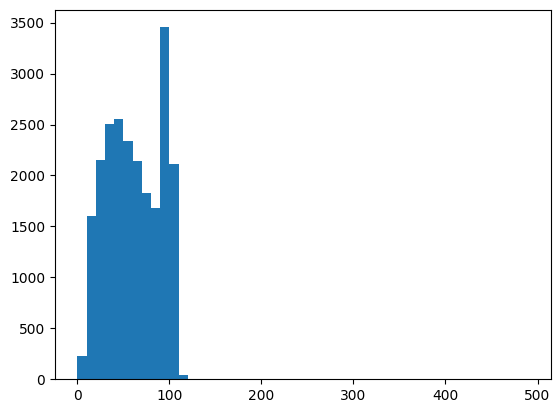

In [ ]:
import matplotlib.pyplot as plt # 导入matplotlib
word_per_comment = [len(comment) for comment in X_train_tokenized_lst]
plt.hist(word_per_comment, bins = np.arange(0,500,10)) # 显示评论长度分布
plt.show()

In [ ]:
from keras.preprocessing.sequence import pad_sequences
max_comment_length = 120 # 设定评论输入长度为120，并填充默认值(如字数少于120)
X_train = pad_sequences(X_train_tokenized_lst, maxlen=max_comment_length)

print("补齐后的张量形状:", X_train.shape)

补齐后的张量形状: (22641, 120)


In [ ]:
from keras.models import Sequential # 导入贯序模型
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN
embedding_vecor_length = 60 # 设定词嵌入向量长度为60
rnn = Sequential() # 贯序模型
rnn.add(Embedding(dictionary_size, embedding_vecor_length,
          input_length=max_comment_length)) # 加入词嵌入层
rnn.add(SimpleRNN(100)) # 加入SimpleRNN层
rnn.add(Dense(10, activation='relu')) # 加入全连接层
rnn.add(Dense(6, activation='softmax')) # 加入分类输出层
rnn.compile(loss='sparse_categorical_crossentropy', #损失函数
            optimizer='adam', # 优化器
            metrics=['acc']) # 评估指标

rnn.build(input_shape=(None, max_comment_length)) # None 代表 batch_size 可以是任意值

print(rnn.summary()) #打印网络模型

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 60)        │     1,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        16,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,176 (4.64 MB)

 Trainable params: 1,217,176 (4.64 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = rnn.fit(X_train, y_train,
          validation_split = 0.3,
          epochs=10,
          batch_size=64)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - acc: 0.5457 - loss: 1.2784 - val_acc: 0.5447 - val_loss: 1.6481
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.5608 - loss: 1.2073 - val_acc: 0.5241 - val_loss: 1.1879
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.5825 - loss: 1.0714 - val_acc: 0.5788 - val_loss: 1.0925
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.6044 - loss: 1.0205 - val_acc: 0.5693 - val_loss: 1.2280
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.6422 - loss: 0.9059 - val_acc: 0.5057 - val_loss: 1.1639
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.6722 - loss: 0.8378 - val_acc: 0.5701 - val_loss: 1.0715
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - acc: 0.7051 - loss: 0.7525 - val_acc: 0.5800 - val_loss: 1.1174
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.6969 - loss: 0.7894 - val_acc: 0.5189 - val_loss: 1.2450
Epoch 9/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms

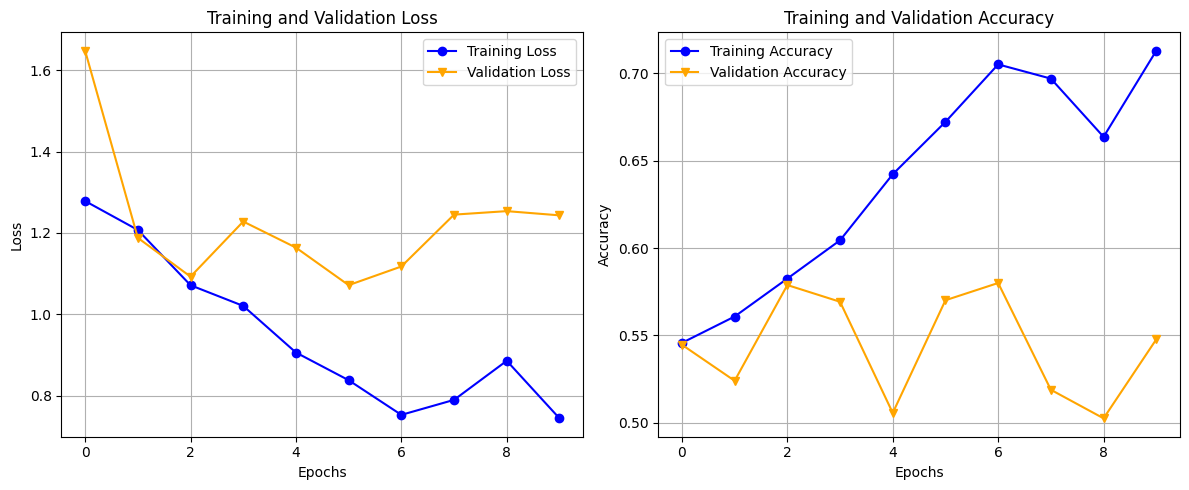

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.figure(figsize=(12, 5))

# --- 图 1：损失函数 (Loss) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='v')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 图 2：准确度 (Accuracy) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['acc'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_acc'], label='Validation Accuracy', color='orange', marker='v')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from keras.models import Sequential # 导入贯序模型
from tensorflow.keras.layers import Embedding, Dense, LSTM
embedding_vecor_length = 60 # 设定词嵌入向量长度为60
lstm = Sequential() # 贯序模型
lstm.add(Embedding(dictionary_size, embedding_vecor_length,
          input_length=max_comment_length)) # 加入词嵌入层
lstm.add(LSTM(100)) # 加入LSTM层
lstm.add(Dense(10, activation='relu')) # 加入全连接层
lstm.add(Dense(6, activation='softmax')) # 加入分类输出层
lstm.compile(loss='sparse_categorical_crossentropy', #损失函数
             optimizer = 'adam', # 优化器
             metrics = ['acc']) # 评估指标
history = lstm.fit(X_train, y_train,
                    validation_split = 0.3,
                    epochs=10,
                    batch_size=64)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - acc: 0.5873 - loss: 1.2088 - val_acc: 0.6030 - val_loss: 0.9830
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.6314 - loss: 0.8828 - val_acc: 0.6046 - val_loss: 0.9893
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.6651 - loss: 0.8054 - val_acc: 0.6100 - val_loss: 0.9444
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.6813 - loss: 0.7536 - val_acc: 0.6121 - val_loss: 0.9351
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.7136 - loss: 0.6956 - val_acc: 0.6214 - val_loss: 0.9656
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.7390 - loss: 0.6412 - val_acc: 0.6175 - val_loss: 1.0136
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.7659 - loss: 0.5839 - val_acc: 0.6083 - val_loss: 1.0348
Epoch 8/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - acc: 0.8004 - loss: 0.5199 - val_acc: 0.6024 - val_loss: 1.0693
Epoch 9/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc

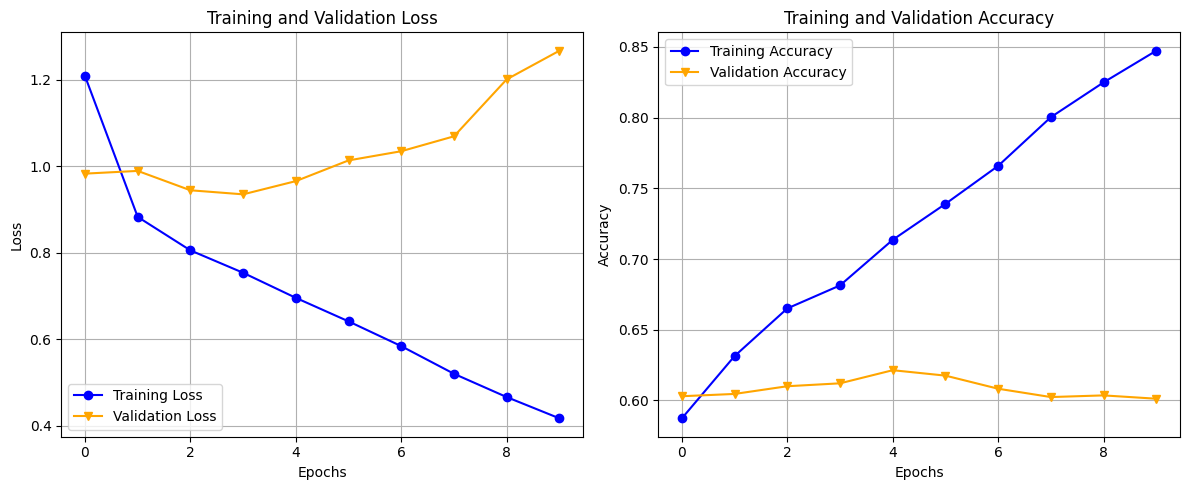

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.figure(figsize=(12, 5))

# --- 图 1：损失函数 (Loss) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='v')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 图 2：准确度 (Accuracy) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['acc'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_acc'], label='Validation Accuracy', color='orange', marker='v')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tohuangjia/new-earth")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/tohuangjia/new-earth/versions/1


In [ ]:
import os

# 列出下载目录下的所有文件
print(os.listdir(path))

# 如果你想在左侧文件栏直接看到它，可以创建一个“软链接”到 /content
!ln -s {path} /content/new-earth

['exoTest.csv', 'exoTrain.csv']


In [ ]:
import numpy as np # 导入NumPy
import pandas as pd # 导入Pandas
df_train = pd.read_csv('/content/new-earth/exoTrain.csv') # 导入训练集
df_test = pd.read_csv('/content/new-earth/exoTest.csv') # 导入测试集
print(df_train.head()) # 输入头几行数据
print(df_train.info()) # 输出训练集信息

   LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4   FLUX.5   FLUX.6  FLUX.7  \
0      2    93.85    83.81    20.10   -26.98   -39.56  -124.71 -135.18   
1      2   -38.88   -33.83   -58.54   -40.09   -79.31   -72.81  -86.55   
2      2   532.64   535.92   513.73   496.92   456.45   466.00  464.50   
3      2   326.52   347.39   302.35   298.13   317.74   312.70  322.33   
4      2 -1107.21 -1112.59 -1118.95 -1095.10 -1057.55 -1034.48 -998.34   

    FLUX.8  FLUX.9  ...  FLUX.3188  FLUX.3189  FLUX.3190  FLUX.3191  \
0   -96.27  -79.89  ...     -78.07    -102.15    -102.15      25.13   
1   -85.33  -83.97  ...      -3.28     -32.21     -32.21     -24.89   
2   486.39  436.56  ...     -71.69      13.31      13.31     -29.89   
3   311.31  312.42  ...       5.71      -3.73      -3.73      30.05   
4 -1022.71 -989.57  ...    -594.37    -401.66    -401.66    -357.24   

   FLUX.3192  FLUX.3193  FLUX.3194  FLUX.3195  FLUX.3196  FLUX.3197  
0      48.57      92.54      39.32      61.42       5.08  

In [ ]:
print(df_train['LABEL'].value_counts())

LABEL
1    5050
2      37
Name: count, dtype: int64


In [ ]:
from sklearn.utils import shuffle # 导入乱序工具
df_train = shuffle(df_train) # 乱序训练集
df_test = shuffle(df_test)  # 乱序测试集

In [ ]:
X_train = df_train.iloc[:, 1:].values # 构建特征集（训练）
y_train = df_train.iloc[:, 0].values # 构建标签集（训练）
X_test = df_test.iloc[:, 1:].values # 构建特征集（测试）
y_test = df_test.iloc[:, 0].values # 构建标签集（测试）
y_train = y_train - 1 # 标签转换成惯用的(0，1)分类
y_test = y_test - 1 # 标签转换成惯用的(0，1)分类
print (X_train) # 打印训练集中的特征
print (y_train) # 打印训练集中的标签

[[-1.0150e+02 -2.8250e+01 -1.4900e+01 ... -5.0620e+01  3.3970e+01
  -2.8970e+01]
 [-4.9515e+02 -4.8173e+02 -3.3771e+02 ...  4.8605e+02  4.7531e+02
   2.7612e+02]
 [-1.1605e+02 -8.3080e+01 -6.1610e+01 ... -2.7950e+01 -3.4280e+01
  -2.0290e+01]
 ...
 [ 1.2817e+02  1.2467e+02  1.1375e+02 ... -3.7800e+00 -1.1030e+01
  -1.4210e+01]
 [ 1.0920e+01  1.4190e+01  1.2520e+01 ... -7.3300e+00 -1.2000e-01
  -6.5800e+00]
 [ 3.5743e+02  3.1859e+02  3.1365e+02 ...  8.7860e+01  7.4920e+01
   4.2620e+01]]
[0 0 0 ... 0 0 0]


In [ ]:
print(X_train.shape)

(5087, 3197)


In [ ]:
X_train = np.expand_dims(X_train, axis=2) # 张量升阶，以满足序列数据集的要求
X_test = np.expand_dims(X_test, axis=2) # 张量升阶，以满足序列数据集的要求

In [ ]:
print(X_train.shape)

(5087, 3197, 1)


In [ ]:
from keras.models import Sequential # 导入序贯模型
from keras import layers # 导入所有类型的层
from tensorflow.keras.optimizers import Adam # 导入优化器
model = Sequential() # 序贯模型
model.add(layers.Conv1D(32, kernel_size=10, strides=4,
          input_shape=(3197, 1))) # 1D CNN层
model.add(layers.MaxPooling1D(pool_size=4, strides=2)) # 池化层
model.add(layers.GRU(256, return_sequences=True)) # 关键，GRU层够要大
model.add(layers.Flatten()) # 展平
model.add(layers.Dropout(0.5)) # Dropout层
model.add(layers.BatchNormalization()) # 批标准化
model.add(layers.Dense(1, activation='sigmoid')) # 分类输出层
opt = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, decay=0.01) # 设置优化器
model.compile(optimizer=opt, # 优化器
              loss = 'binary_crossentropy', # 交叉熵
              metrics=['accuracy']) # 准确率

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
history = model.fit(X_train,y_train, # 训练集
                    validation_split = 0.2, # 部分训练集数据拆分成验证集
                    batch_size = 128, # 批量大小
                    epochs = 4, # 训练轮次
                    shuffle = True) # 乱序

Epoch 1/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.6726 - loss: 0.6402 - val_accuracy: 0.9754 - val_loss: 0.2473
Epoch 2/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9044 - loss: 0.2938 - val_accuracy: 0.9833 - val_loss: 0.1540
Epoch 3/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9678 - loss: 0.1547 - val_accuracy: 0.9843 - val_loss: 0.0906
Epoch 4/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9892 - loss: 0.0901 - val_accuracy: 0.9843 - val_loss: 0.0814


In [ ]:
from sklearn.metrics import classification_report # 分类报告
from sklearn.metrics import confusion_matrix # 混淆矩阵
y_prob = model.predict(X_test) # 对测试集进行预测
y_pred =  np.where(y_prob > 0.5, 1, 0) #将概率值转换成真值
cm = confusion_matrix(y_pred, y_test)
print('Confusion matrix:\n', cm, '\n')
print(classification_report(y_pred, y_test))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Confusion matrix:
 [[565   5]
 [  0   0]] 

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       570
           1       0.00      0.00      0.00         0

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       1.00      0.99      1.00       570



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(y_prob)

[[0.03854263]
 [0.02805744]
 [0.00691751]
 [0.02857345]
 [0.00728204]
 [0.03261753]
 [0.03058197]
 [0.05610985]
 [0.04488858]
 [0.04767323]
 [0.04767814]
 [0.01271965]
 [0.03955647]
 [0.02183385]
 [0.04478187]
 [0.01693984]
 [0.03386607]
 [0.03752703]
 [0.02144506]
 [0.0730285 ]
 [0.02359024]
 [0.01416609]
 [0.0427341 ]
 [0.03375973]
 [0.02674249]
 [0.01230252]
 [0.03688562]
 [0.06110058]
 [0.04013811]
 [0.02648998]
 [0.01476145]
 [0.00660906]
 [0.00925354]
 [0.01593052]
 [0.01997596]
 [0.00715482]
 [0.04711687]
 [0.03713746]
 [0.01321518]
 [0.03164605]
 [0.01976827]
 [0.07754456]
 [0.03231366]
 [0.01564883]
 [0.03771275]
 [0.05067289]
 [0.03596884]
 [0.03827004]
 [0.00642914]
 [0.04149364]
 [0.03395215]
 [0.02627379]
 [0.02674852]
 [0.02102682]
 [0.02784911]
 [0.03291127]
 [0.01258946]
 [0.07028229]
 [0.0244515 ]
 [0.02890031]
 [0.06006006]
 [0.03058869]
 [0.03784125]
 [0.03832491]
 [0.03098568]
 [0.03452022]
 [0.02928979]
 [0.0087599 ]
 [0.01998414]
 [0.0517387 ]
 [0.0319306 ]
 [0.05

In [ ]:
y_pred =  np.where(y_prob > 0.13, 1, 0) # 进行阈值调整
cm = confusion_matrix(y_pred, y_test)
print('Confusion matrix:\n', cm, '\n')
print(classification_report(y_pred, y_test))

Confusion matrix:
 [[563   4]
 [  2   1]] 

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       567
           1       0.20      0.33      0.25         3

    accuracy                           0.99       570
   macro avg       0.60      0.66      0.62       570
weighted avg       0.99      0.99      0.99       570



In [ ]:
from keras import layers # 导入各种层
from keras.models import Model # 导入模型
from tensorflow.keras.optimizers import Adam # 导入Adam优化器
input = layers.Input(shape=(3197, 1)) # Input
# 通过函数式API构建模型
x = layers.Conv1D(32, kernel_size=10, strides=4)(input)
x = layers.MaxPooling1D(pool_size=4, strides=2)(x)
x = layers.GRU(256, return_sequences=True)(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)
output = layers.Dense(1, activation='sigmoid')(x) # Output
model = Model(input, output)
model.summary() # 显示模型的输出
opt = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, decay=0.01) # 设置优化器
model.compile(optimizer=opt, # 优化器
              loss = 'binary_crossentropy', # 交叉熵
              metrics=['accuracy']) # 准确率

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3197, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 797, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 397, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 397, 256)       │       222,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 101632)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 101632)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 101632)         │       406,528 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       101,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731,233 (2.79 MB)

 Trainable params: 527,969 (2.01 MB)

 Non-trainable params: 203,264 (794.00 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
# 翻转序列
X_train_rev = [X[::-1] for X in X_train]
X_test_rev = [X[::-1] for X in X_test]
# 维度升阶
X_train = np.expand_dims(X_train, axis=2)
X_train_rev = np.expand_dims(X_train_rev, axis=2)
X_test = np.expand_dims(X_test, axis=2)
X_test_rev = np.expand_dims(X_test_rev, axis=2)

In [ ]:
# 构建正向网络
input_1 = layers.Input(shape=(3197, 1))
x = layers.GRU(32, return_sequences=True)(input_1)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
# 构建逆向网络
input_2 = layers.Input(shape=(3197, 1))
y = layers.GRU(32, return_sequences=True)(input_2)
y = layers.Flatten()(y)
y = layers.Dropout(0.5)(y)
# 连接两个网络
z = layers.concatenate([x, y])
output = layers.Dense(1, activation='sigmoid')(z)
model = Model([input_1,input_2], output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3197, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 3197, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 3197, 32)  │      3,360 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 3197, 32)  │      3,360 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 102304)    │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 102304)    │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 102304)    │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 102304)    │          0 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 204608)    │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │    204,609 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 211,329 (825.50 KB)

 Trainable params: 211,329 (825.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

# 定义优化器（注意参数名是 learning_rate）
opt = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999)

# 编译模型
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',  # 二分类任务的标准损失函数
    metrics=['accuracy']         # 训练时显示准确率
)

In [ ]:
history = model.fit([X_train, X_train_rev], y_train,
          validation_split = 0.2,
          epochs=10,
          batch_size=128,
          shuffle = True
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.9688 - loss: 0.3251 - val_accuracy: 0.9951 - val_loss: 0.2194
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.9912 - loss: 0.2122 - val_accuracy: 0.9902 - val_loss: 0.0901
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.9877 - loss: 0.0796 - val_accuracy: 0.9951 - val_loss: 0.0459
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.9919 - loss: 0.0458 - val_accuracy: 0.9931 - val_loss: 0.0343
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.9931 - loss: 0.0316 - val_accuracy: 0.9951 - val_loss: 0.0331
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.9951 - loss: 0.0218 - val_accuracy: 0.9951 - val_loss: 0.0318
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.9956 - loss: 0.0171 - val_accuracy: 0.9951 - val_loss: 0.0358
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.9963 - loss: 0.0164 - val_accuracy: 0

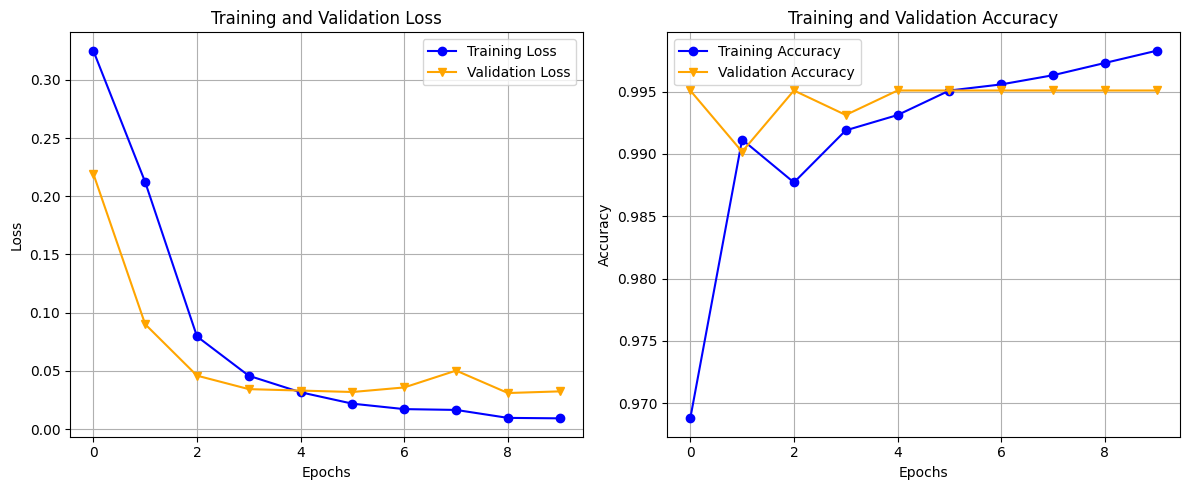

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.figure(figsize=(12, 5))

# --- 图 1：损失函数 (Loss) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='v')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 图 2：准确度 (Accuracy) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='v')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --- 正向路径 ---
input_1 = layers.Input(shape=(3197, 1))
x = layers.Conv1D(32, kernel_size=10, strides=4, activation='relu')(input_1) # 降维
x = layers.MaxPooling1D(pool_size=4, strides=2)(x) # 进一步压缩
x = layers.GRU(64, return_sequences=True)(x) # 处理压缩后的序列
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)

# --- 逆向路径 ---
input_2 = layers.Input(shape=(3197, 1))
y = layers.Conv1D(32, kernel_size=10, strides=4, activation='relu')(input_2) # 降维
y = layers.MaxPooling1D(pool_size=4, strides=2)(y) # 进一步压缩
y = layers.GRU(64, return_sequences=True)(y) # 处理压缩后的序列
y = layers.Flatten()(y)
y = layers.Dropout(0.5)(y)

# --- 合并 ---
z = layers.concatenate([x, y])
z = layers.BatchNormalization()(z) # 让训练更稳定
output = layers.Dense(1, activation='sigmoid')(z)

model = Model([input_1, input_2], output)

In [ ]:
# 建议将学习率调小一点，因为双路模型参数较多
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.00005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 开始训练
history = model.fit(
    x=[X_train, X_train_rev], # 同时喂入正向和逆向数据
    y=y_train,
    validation_split=0.2,             # 拿出20%做验证
    epochs=20,                        # 先跑20轮观察趋势
    batch_size=64,                    # 兼顾速度与内存
    shuffle=True                      # 每轮打乱顺序
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6309 - loss: 0.6998 - val_accuracy: 0.9244 - val_loss: 0.3852
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8184 - loss: 0.4183 - val_accuracy: 0.9892 - val_loss: 0.2078
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9159 - loss: 0.2636 - val_accuracy: 0.9951 - val_loss: 0.1280
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9567 - loss: 0.1799 - val_accuracy: 0.9951 - val_loss: 0.0911
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9735 - loss: 0.1264 - val_accuracy: 0.9951 - val_loss: 0.0681
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9845 - loss: 0.0961 - val_accuracy: 0.9951 - val_loss: 0.0557
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9894 - loss: 0.0756 - val_accuracy: 0.9951 - val_loss: 0.0464
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9921 - loss: 0.0573 - val_accuracy: 0.9951 - v

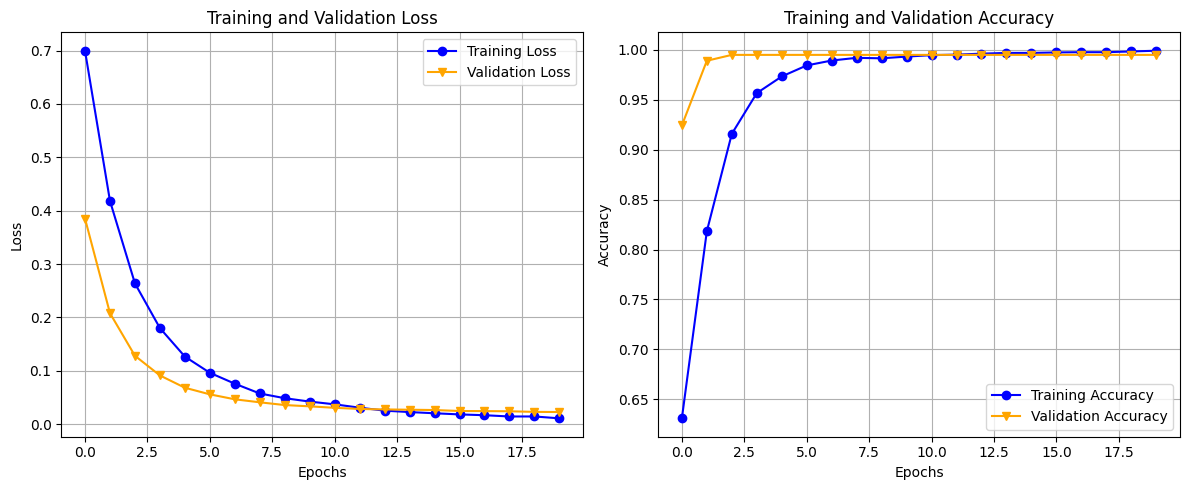

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.figure(figsize=(12, 5))

# --- 图 1：损失函数 (Loss) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='v')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 图 2：准确度 (Accuracy) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='v')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. 在测试集上进行预测
y_prob = model.predict([X_test, X_test_rev])
y_pred = (y_prob > 0.5).astype(int)

# 2. 打印混淆矩阵
cm = confusion_matrix(y_pred, y_test)
print('Confusion matrix:\n', cm, '\n')

# 3. 打印详细报告
print("\nClassification Report:\n", classification_report(y_pred, y_test))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Confusion matrix:
 [[565   5]
 [  0   0]] 


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       570
           1       0.00      0.00      0.00         0

    accuracy                           0.99       570
   macro avg       0.50      0.50      0.50       570
weighted avg       1.00      0.99      1.00       570



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 修改训练代码
weights = {0: 1, 1: 100} # 尝试给 1 类别 100 倍的权重

history = model.fit(
    x=[X_train, X_train_rev],
    y=y_train,
    class_weight=weights,  # 关键参数
    epochs=30,             # 适当增加轮数
    batch_size=32,         # 减小 Batch Size 让模型观察更细致
    validation_split=0.2,
    shuffle=True
)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9855 - loss: 0.2467 - val_accuracy: 0.9843 - val_loss: 0.0554
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9860 - loss: 0.0619 - val_accuracy: 0.9931 - val_loss: 0.0325
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9934 - loss: 0.0562 - val_accuracy: 0.9931 - val_loss: 0.0314
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9948 - loss: 0.0367 - val_accuracy: 0.9941 - val_loss: 0.0260
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9966 - loss: 0.0273 - val_accuracy: 0.9941 - val_loss: 0.0238
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9963 - loss: 0.0388 - val_accuracy: 0.9931 - val_loss: 0.0245
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9968 - loss: 0.0278 - val_accuracy: 0.9941 - val_loss: 0.0223
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9985 - loss: 0.0260 - val_accu

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. 在测试集上进行预测
y_prob = model.predict([X_test, X_test_rev])
y_pred = (y_prob > 0.5).astype(int)

# 2. 打印混淆矩阵
cm = confusion_matrix(y_pred, y_test)
print('Confusion matrix:\n', cm, '\n')

# 3. 打印详细报告
print("\nClassification Report:\n", classification_report(y_pred, y_test))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Confusion matrix:
 [[565   4]
 [  0   1]] 


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       569
           1       0.20      1.00      0.33         1

    accuracy                           0.99       570
   macro avg       0.60      1.00      0.66       570
weighted avg       1.00      0.99      1.00       570



In [ ]:
# 尝试降低门槛
y_pred_bold = (y_prob > 0.1).astype(int)
new_cm = confusion_matrix(y_test, y_pred_bold)
print("降低阈值后的矩阵:\n", new_cm)

降低阈值后的矩阵:
 [[565   0]
 [  1   4]]
